# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 2 - Visualisations
creation of maps, graphs and more

In [2]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
!pip install h3
import h3
import matplotlib.patches as mpatches

NameError: name 'admin_city' is not defined

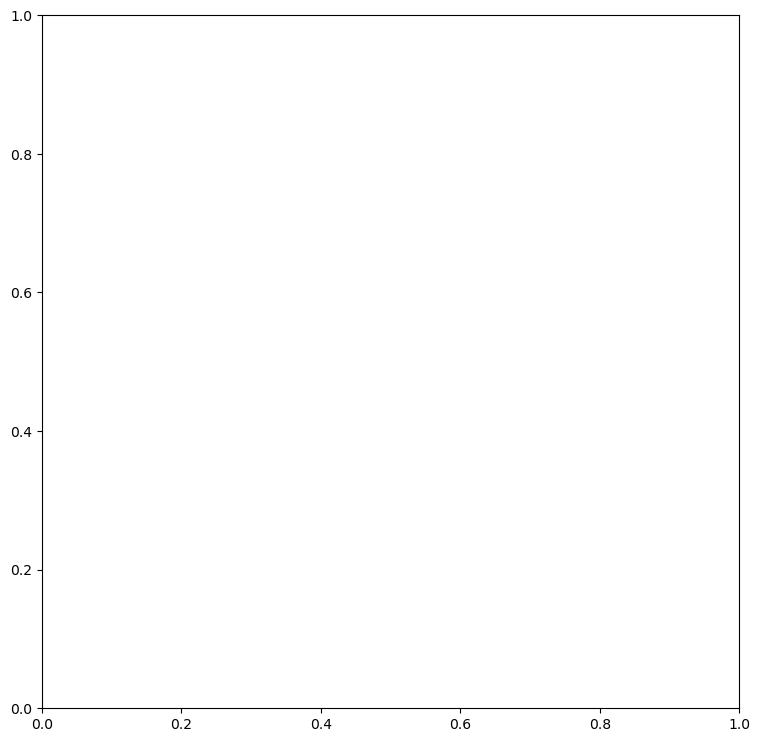

In [3]:
#greens from Open Data Austria, and blues from OSM:

f, ax = plt.subplots(1, 1, figsize=(9, 9))

admin_city.plot(ax=ax, color='none', edgecolor='k')
gdf_green.plot(ax=ax, cmap='Greens')
blue_clipped.plot(ax=ax, cmap='Blues')
ax.axis('off')

plt.savefig("output/vienna_green_blue_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot average income by census district (Zahlbezirke)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='avg_income',     
    cmap='OrRd',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Average Income by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/avg_income_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot average income by district (Bezirke)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

districts.plot(
    column='district_avgincome',     
    cmap='OrRd',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
#districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Average Income by District", fontsize=12)
ax.axis('off')

plt.savefig("output/district_avg_income_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='unemprate',      
    cmap='magma',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Unemployment Rate by Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/unemp_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot average income by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='university_share',     
    cmap='PuOr',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,             
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("University Graduation Rate per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/uni_grad_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot SSI by census district
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_census.plot(
    column='SSI',      
    cmap='inferno',              
    linewidth=0.5,           
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("Social Status Index (SSI) per Census District", fontsize=12)
ax.axis('off')

plt.savefig("output/ssi_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot SSI by district (Bezirke)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

districts.plot(
    column='district_SSI',     
    cmap='inferno',              
    linewidth=0.5,            
    edgecolor='black',        
    legend=True,              
    ax=ax
)

# Overlaying district boundaries
#districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_title("SSI by District", fontsize=12)
ax.axis('off')

plt.savefig("output/district_ssi_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot everything together
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Plot SSI as choropleth
gdf_census.plot(
    column='SSI',
    cmap='PuOr',     
    linewidth=0.3,
    edgecolor='gray',
    legend=True,
    ax=ax
)

# Overlay green and blue spaces
gdf_green.plot(ax=ax, cmap='Greens', alpha=0.4, edgecolor='darkgreen') #austrian governmental data
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue') #OSM data

# Overlaying district boundaries, and city boundaries
admin_city.plot(ax=ax, color='none', edgecolor='black', linewidth=1.2)
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

# Tidy up
ax.set_title("Social Status Index (SSI) & Green/Blue Spaces in Vienna", fontsize=16)
ax.axis('off')

plt.tight_layout()

plt.savefig("output/ssi_ubgs_map.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))

# Plot without legend
housing_districts_plot = housing_districts.plot(
    column='avg_price_years',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False 
)

# Create a scalar mappable for the colorbar
norm = mpl.colors.Normalize(
    vmin=housing_districts['avg_price_years'].min(),
    vmax=housing_districts['avg_price_years'].max()
)
sm = mpl.cm.ScalarMappable(cmap='Reds', norm=norm)
sm._A = []  # required for matplotlib <3.1

# Adding the colorbar manually
cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.3,              
    pad=0.01,                
    orientation='vertical',
    location='right'         
)

# Remove ticks and add title to the colorbar
cbar.ax.set_yticks([])
cbar.ax.set_title('↑ Price', fontsize=10, pad=10)

# Final plot tweaks
ax.set_title("Apartment Prices per m² in Vienna Districts (Average Price for years 2015-2023)", fontsize=12)
ax.axis('off')
plt.show()

In [ ]:
# Setup plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot housing prices as base choropleth
housing_districts.plot(
    column='avg_price_years',
    cmap='OrRd',
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    legend=False  
)

# Overlay green and blue spaces
green_clipped.plot(ax=ax, color='green', alpha=0.3, edgecolor='darkgreen', linewidth=0.3)
blue_clipped.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')

# Add colorbar manually
norm = mpl.colors.Normalize(vmin=housing_districts['avg_price_years'].min(), vmax=housing_districts['avg_price_years'].max())
sm = mpl.cm.ScalarMappable(cmap='OrRd', norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.3, pad=0.01)
cbar.ax.set_title('€ / m²', fontsize=10)

# Title & layout
ax.set_title("Vienna Apartment Prices (Average Price for years 2015-2023) with Green and Blue Spaces", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()